**GROUPE 7 \:**

QUENETTE Léo - 22411674

LEMRABOTT Rim - 22401063

KECHAOU Sonia - 21900155

RUIZ Fannie - 22123922

# Partie 2 : CLIP

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!git clone https://github.com/LeoQUENETTE/Projet-ML2.git
%cd Projet-ML2
!git checkout clip
!git pull

In [2]:
import sys
my_local_drive='/content/gdrive/My Drive/Colab Notebooks/ML2/ProjetClip'
sys.path.append(my_local_drive)
%cd $my_local_drive

/content/gdrive/My Drive/Colab Notebooks/ML2/ProjetClip


In [3]:
import os
import pandas as pd
import re
import numpy as np
import random
import zipfile
import requests
import io
import math
from pathlib import Path
#import cv2

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.utils import register_keras_serializable, to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import load_model
from tensorflow.keras.metrics import Mean
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model
from tensorflow.keras.models import load_model

'''
from src.classes.SmallBert import SmallBERT
from src.classes.SmallBertClassification import SmallBERTForClassification
from src.classes.UsefullClasses import PositionalEmbedding
from src.classes.TransformerBlock import TransformerBlock
'''

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Pour utiliser au mieux le GPU
AUTOTUNE = tf.data.AUTOTUNE

In [4]:
def plot_history_simple(history):
    """
    Trace côte à côte les courbes Loss et Accuracy (train/val si dispo)
    à partir d'un objet Keras History.
    """
    hist = history.history

    # compatibilité anciennes versions ("acc"/"val_acc")
    acc_key = "accuracy" if "accuracy" in hist else "acc"
    val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_acc"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss" in hist:
        axes[0].plot(hist["loss"], label="train")
    if "val_loss" in hist:
        axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # --- Accuracy ---
    if acc_key in hist:
        axes[1].plot(hist[acc_key], label="train")
        if val_acc_key in hist:
            axes[1].plot(hist[val_acc_key], label="val")
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
    else:
        axes[1].set_visible(False)  # si pas d'accuracy, on masque le 2e plot

    plt.tight_layout()
    plt.show()

In [5]:
@tf.keras.utils.register_keras_serializable()
class SmallBERTForClassification(keras.Model):
    def __init__(self, sequence_length, vocab_size, embed_dim, num_heads, ff_dim, num_layers, dropout_rate = 0.3,**kwargs):
        super().__init__(**kwargs)
        self.encoder = SmallBERT(sequence_length, vocab_size, embed_dim, num_heads, ff_dim, num_layers)

        self.dropout = layers.Dropout(dropout_rate, name="dropout_nb1")
        self.dense = layers.Dense(128, activation="relu", name="dense_nb1")
        self.batch_norm = layers.BatchNormalization(name="batch_nb1")

        self.dropout2 = layers.Dropout(dropout_rate, name="dropout_nb2")
        self.dense2 = layers.Dense(64, activation="relu", name="dense_nb2")

        self.output_layer = layers.Dense(4, activation="softmax", name="dense_nb1")
        self.dropout_rate = dropout_rate

    def call(self, inputs, training=False):
        x = self.encoder(inputs, training=training)
        mean_pool = tf.reduce_mean(x, axis=1)
        max_pool = tf.reduce_max(x, axis=1)
        x = tf.concat([mean_pool, max_pool], axis=-1)

        x = self.dropout(x, training=training)
        x = self.dense(x)
        x = self.batch_norm(x, training=training)

        x = self.dropout2(x, training=training)
        x = self.dense2(x)

        return self.output_layer(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.encoder.pos_embedding.sequence_length,
            "vocab_size": self.encoder.pos_embedding.vocab_size,
            "embed_dim": self.encoder.pos_embedding.embed_dim,
            "num_heads": self.encoder.transformer_blocks[0].att.num_heads,
            "ff_dim": self.encoder.transformer_blocks[0].ffn.layers[0].units,
            "num_layers": len(self.encoder.transformer_blocks),
            "dropout_rate" : self.dropout_rate
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)
#---------------------
@tf.keras.utils.register_keras_serializable()
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads,ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.att = layers.MultiHeadAttention(num_heads=num_heads,
                                             key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False, mask=None):
        seq_len = tf.shape(inputs)[1]
        attn_mask = None
        if mask is not None:
            attn_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.float32)
            attn_mask = tf.tile(attn_mask, [1, seq_len, 1])

        attn_output = self.att(inputs, inputs, inputs, attention_mask=attn_mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

        def get_config(self):
            config = super().get_config()
            config.update({
                "embed_dim": self.att.key_dim,
                "num_heads": self.att.num_heads,
                "ff_dim": self.ffn.layers[0].units,
                "dropout_rate": self.dropout1.rate,
            })
            return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)
#---------------------
@tf.keras.utils.register_keras_serializable()
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(input_dim=vocab_size,
                                                 output_dim=embed_dim)
        self.position_embeddings = layers.Embedding(input_dim=sequence_length,
                                                    output_dim=embed_dim)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(0, length)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return tf.not_equal(inputs, 0)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config
#---------------------
@register_keras_serializable()
class SmallBERT(tf.keras.Model):
    def __init__(self, sequence_length, vocab_size, embed_dim, num_heads,
                 ff_dim, num_layers, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.num_layers = num_layers

        self.pos_embedding = PositionalEmbedding(sequence_length, vocab_size,
                                                 embed_dim)

        self.transformer_blocks = [
            TransformerBlock(embed_dim,
                             num_heads, ff_dim) for _ in range(num_layers)
        ]
        self.layernorm = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout = tf.keras.layers.Dropout(0.1)

    def call(self, inputs, training=False):
        x = self.pos_embedding(inputs)
        for block in self.transformer_blocks:
            x = block(x, training=training)
        x = self.layernorm(x)
        return self.dropout(x, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "num_layers": self.num_layers,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)
#----------------------------------
@register_keras_serializable()
class MaskedMean(layers.Layer):
  # Retourne la moyenne des mots sans être trop influencé par PAD
    def call(self, inputs):
        seq_out, token_ids = inputs   # (B,L,D), (B,L)
        mask = tf.cast(tf.not_equal(token_ids, 0), seq_out.dtype)  # PAD=0
        mask = tf.expand_dims(mask, -1)        # (B,L,1)
        summed = tf.reduce_sum(seq_out * mask, axis=1)             # (B,D)
        counts = tf.reduce_sum(mask, axis=1)                        # (B,1)
        return summed / tf.maximum(counts, 1.0)

## Élagage des modèles image et texte

In [6]:
saved_models_path = "./models_forclip/"

model_images = load_model(os.path.join(saved_models_path, "best_image_classif.keras"))
print("Modèle Image")
model_images.summary()

Modèle Image


Model: "Classif_Images_for_Clip"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Layer (InputLayer)        │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_1 (Conv2D)               │ (32, 222, 222, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_1 (MaxPooling2D)   │ (32, 111, 111, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (32, 109, 109, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_2 (MaxPooling2D)   │ (32, 54, 54, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_3 (Conv2D)               │ (32, 52, 52, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_3 (MaxPooling2D)   │ (32, 26, 26, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_4 (Conv2D)               │ (32, 24, 24, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_4 (MaxPooling2D)   │ (32, 12, 12, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_5 (Conv2D)               │ (32, 10, 10, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_5 (MaxPooling2D)   │ (32, 5, 5, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_6 (Conv2D)               │ (32, 3, 3, 32)         │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_6 (MaxPooling2D)   │ (32, 1, 1, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (32, 1, 1, 128)        │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (32, 100)              │        12,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (32, 4)                │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,994 (757.79 KB)

 Trainable params: 64,664 (252.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 129,330 (505.20 KB)

In [7]:
model_texte = load_model(os.path.join(saved_models_path, "best_smallbert.keras"))
print("Modèle Texte")
model_texte.summary()

Modèle Texte


Model: "SmallBERT_classif"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (32, 32)          │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ small_bert_13       │ (32, 32, 128)     │  1,944,832 │ text_input[0][0]  │
│ (SmallBERT)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean_no_pad         │ (32, 128)         │          0 │ small_bert_13[0]… │
│ (MaskedMean)        │                   │            │ text_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_nb1         │ (32, 128)         │          0 │ mean_no_pad[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_nb1 (Dense)   │ (32, 128)         │     16,512 │ dropout_nb1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_nb1           │ (32, 128)         │        512 │ dense_nb1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_nb2         │ (32, 128)         │          0 │ batch_nb1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_nb2 (Dense)   │ (32, 128)         │     16,512 │ dropout_nb2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_68 (Dense)    │ (32, 4)           │        516 │ dense_nb2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,936,142 (22.64 MB)

 Trainable params: 1,978,628 (7.55 MB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 3,957,258 (15.10 MB)

In [8]:
learning_rate=1e-3
loss_images="categorical_crossentropy"
loss_text="sparse_categorical_crossentropy"
metrics=["accuracy"]

cropped_model_images = model_images.layers[-3].output
new_model_images = Model(inputs=model_images.input, outputs=cropped_model_images)
new_model_images.trainable = True
new_model_images.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Layer (InputLayer)        │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_1 (Conv2D)               │ (32, 222, 222, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_1 (MaxPooling2D)   │ (32, 111, 111, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (32, 109, 109, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_2 (MaxPooling2D)   │ (32, 54, 54, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_3 (Conv2D)               │ (32, 52, 52, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_3 (MaxPooling2D)   │ (32, 26, 26, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_4 (Conv2D)               │ (32, 24, 24, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_4 (MaxPooling2D)   │ (32, 12, 12, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_5 (Conv2D)               │ (32, 10, 10, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_5 (MaxPooling2D)   │ (32, 5, 5, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_6 (Conv2D)               │ (32, 3, 3, 32)         │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_6 (MaxPooling2D)   │ (32, 1, 1, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (32, 1, 1, 128)        │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (32, 128)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,360 (200.62 KB)

 Trainable params: 51,360 (200.62 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cropped_model_text = model_texte.layers[-2].output
new_model_text = Model(inputs=model_texte.input, outputs=cropped_model_text)
new_model_text.trainable = True
new_model_text.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (32, 32)          │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ small_bert_13       │ (32, 32, 128)     │  1,944,832 │ text_input[0][0]  │
│ (SmallBERT)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean_no_pad         │ (32, 128)         │          0 │ small_bert_13[0]… │
│ (MaskedMean)        │                   │            │ text_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_nb1         │ (32, 128)         │          0 │ mean_no_pad[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_nb1 (Dense)   │ (32, 128)         │     16,512 │ dropout_nb1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_nb1           │ (32, 128)         │        512 │ dense_nb1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_nb2         │ (32, 128)         │          0 │ batch_nb1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_nb2 (Dense)   │ (32, 128)         │     16,512 │ dropout_nb2[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,978,368 (7.55 MB)

 Trainable params: 1,978,112 (7.55 MB)

 Non-trainable params: 256 (1.00 KB)

In [10]:
print(new_model_images.output)
print(new_model_text.output)

<KerasTensor shape=(32, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_27>
<KerasTensor shape=(32, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_57>


## Dataset

In [11]:
def make_clip_dataset_smallbert(
    df,
    tokenizer_layer,
    batch_size=32,
    shuffle=True,
    drop_remainder=True,
    cache=True,
    seed=42,
):
    """
    Construit un tf.data.Dataset avec en sortie (images, token_ids) pour CLIP.
    """
    # On récupère le fichier captions.csv qui a tout
    image_paths = df["image_path"].astype(str).tolist()
    captions    = df["caption"].fillna("").astype(str).tolist()

    # Récupération du répertoire des images
    root = Path(dataset_dir)
    full_paths = [str(root / p) for p in image_paths]

    # Création du dataset d'image
    ds = tf.data.Dataset.from_tensor_slices((full_paths, captions))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(full_paths), seed=seed,
                        reshuffle_each_iteration=True)

    # Chargement d'une ensemble d'images normalisées et de tokens (le texte)
    IMAGE_H, IMAGE_W = 224, 224  # même que image_size

    def load_sample(img_path, caption):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        #img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
        img = img / 255.0
        tokens = tf.cast(tokenizer_layer(caption), tf.int32)  # (L,)
        # x = dict des 2 entrées, pour forcer à ne pas avoir de  y
        return {"image_input": img, "text_input": tokens}

    # Pour utiliser le cache et pouvoir faire les traitements en //
    ds = ds.map(load_sample, num_parallel_calls=AUTOTUNE)
    if cache:
        ds = ds.cache()
    # si drop_remainder=True on vire le dernier batch
    # s'il n'est pas de la bonne taille
    ds = ds.batch(batch_size, drop_remainder=drop_remainder).prefetch(AUTOTUNE)
    return ds

# Quand le tokenizer est initialisé, un exemple d'appel que vous pourrez faire :
# train_dataset = make_clip_dataset_smallbert(captions_csv_path,
#                                       text_tokenizer,
#                                       batch_size=64)

## Construction du CLIP

In [12]:
@register_keras_serializable()
class L2Normalize(layers.Layer):
    def __init__(self, axis=-1, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({"axis": self.axis})
        return config

In [13]:
# Perte contrastive CLIP
# Le but de cette fonction est d’aligner les embeddings d’images et de textes
# correspondants dans un espace latent partagé. Elle est inspirée du papier
# CLIP, où l'on entraîne le modèle à prédire quelle image correspond à quel
# texte et réciproquement.

@register_keras_serializable()
class ClipLossLayer(layers.Layer):
    def __init__(self, temperature=0.07, **kwargs):
        super().__init__(**kwargs)
        self.temperature = temperature
        self.clip_loss_metric = tf.keras.metrics.Mean(name="clip_loss")

    def call(self, inputs):
        # l'inputs est forcément (img, txt) ou [img, txt]
        img, txt = inputs  # (B, D) attention il faut avoir L2-normalisés !!

        # Matrice des similarités (cosinus parce qu'on a L2 et ça simplifie)
        logits = tf.matmul(img, txt, transpose_b=True) / self.temperature

        # Les Labels implicites : c'est la diagonale
        labels = tf.range(tf.shape(logits)[0])

        li = tf.keras.losses.sparse_categorical_crossentropy(labels,
                                                             logits,
                                                             from_logits=True)
        lt = tf.keras.losses.sparse_categorical_crossentropy(labels,
                                                          tf.transpose(logits),
                                                          from_logits=True)
        loss = tf.reduce_mean(li + lt) / 2.0

        # Ca c'est super important car on ajoute la loss au graphe
        # du modèle et ça nous simplifie la vie
        # après on met à jour la métrique interne si on veut la suivre
        self.add_loss(loss)
        self.clip_loss_metric.update_state(loss)

        # On retourne un TUPLE de tenseurs(surtout pas une liste)
        # dc facile à récupérer
        return (img, txt)

    def get_config(self):
        return {**super().get_config(), "temperature": self.temperature}

In [14]:
def create_clip_model(learning_rate=1e-3):
  input1 = Input(shape=(224, 224, 3), batch_size=32, name="image_input")
  input2 = Input(shape=(32,), batch_size=32, name="text_input")

  new_model_images.name = "model_image"
  new_model_text.name = "model_text"

  img_emb = new_model_images(input1)
  txt_emb = new_model_text(input2)

  img_emb_norm = L2Normalize()(img_emb)
  txt_emb_norm = L2Normalize()(txt_emb)

  img_emb, txt_emb = ClipLossLayer()([img_emb_norm, txt_emb_norm])

  model_clip = Model(inputs=[input1, input2], outputs=[img_emb, txt_emb], name="Clip")

  model_clip.compile(optimizer=Adam(learning_rate))
  model_clip.summary()

  return model_clip

In [19]:
def train_clip_model(model, train_ds, test_ds, val_ds, model_save_path, epochs, patience=3):
  callbacks = [
    EarlyStopping(monitor="val_clip_loss", mode='min', patience=patience, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(model_save_path, "best_clip.keras"), monitor='val_clip_loss', mode='min', save_best_only=True, verbose=1)
  ]

  model_history = model.fit(
    x=train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
    batch_size=32,
    verbose=1
  )

  # Évaluation
  clip_loss, loss = model.evaluate(test_ds)
  print(f"TEST Clip Loss: {clip_loss}")
  plot_history_simple(model_history)

  return model

## Entrainement du Clip

In [16]:
maxlen = 32
vectorize_layer = tf.keras.layers.TextVectorization(
            output_mode='int',
            output_sequence_length=maxlen)
vectorize_layer.set_vocabulary(os.path.join(saved_models_path, "vocab.txt"))

In [17]:
dataset_dir = "./flickr_subset2"
captions_csv_path = os.path.join(dataset_dir, "captions.csv")
df = pd.read_csv(captions_csv_path)

train, test = train_test_split(df, test_size=0.2, shuffle=True)
train, val = train_test_split(train, test_size=0.2, shuffle=True)

ds_train = make_clip_dataset_smallbert(train, vectorize_layer)
ds_test = make_clip_dataset_smallbert(test, vectorize_layer)
ds_val = make_clip_dataset_smallbert(val, vectorize_layer)

# Résultat :
# 'image_input': (32, 224, 224, 3) : ok
# 'text_input': (32, 32) : ok
# Images normalisées : ok
# Tokenisation phrases : ok

'\nres_train = next(iter(ds_train))\nres_test = next(iter(ds_test))\nres_vas = next(iter(ds_val))\n\nprint(res_train["image_input"].shape, res_train["text_input"].shape)\nprint(res_test["image_input"].shape, res_test["text_input"].shape)\nprint(res_vas["image_input"].shape, res_vas["text_input"].shape)\nprint(res_train["image_input"][:2], res_train["text_input"][:2])\nprint(res_test["image_input"][:2], res_test["text_input"][:2])\nprint(res_vas["image_input"][:2], res_vas["text_input"][:2])\n'

Model: "Clip"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (32, 224, 224, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (32, 32)          │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model_image         │ (32, 128)         │     51,360 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ model_text          │ (32, 128)         │  1,978,368 │ text_input[0][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l2_normalize_2      │ (32, 128)         │          0 │ model_image[1][0] │
│ (L2Normalize)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l2_normalize_3      │ (32, 128)         │          0 │ model_text[1][0]  │
│ (L2Normalize)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clip_loss_layer_1   │ [(32, 128), (32,  │          0 │ l2_normalize_2[0… │
│ (ClipLossLayer)     │ 128)]             │            │ l2_normalize_3[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,029,728 (7.74 MB)

 Trainable params: 2,029,472 (7.74 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - clip_loss: 3.6647 - loss: 3.6647 
Epoch 1: val_clip_loss improved from inf to 3.48411, saving model to ./models_forclip/best_clip.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 187s 14s/step - clip_loss: 3.6613 - loss: 3.6613 - val_clip_loss: 3.4841 - val_loss: 3.4841
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - clip_loss: 3.5691 - loss: 3.5691
Epoch 2: val_clip_loss improved from 3.48411 to 3.46698, saving model to ./models_forclip/best_clip.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - clip_loss: 3.5690 - loss: 3.5690 - val_clip_loss: 3.4670 - val_loss: 3.4670
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - clip_loss: 3.5329 - loss: 3.5329
Epoch 3: val_clip_loss did not improve from 3.46698
12/12 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - clip_loss: 3.5330 - loss: 3.5330 - val_clip_loss: 3.4672 - val_loss: 3.4672
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - clip_loss: 3.5234 - loss: 3.5234
Epoch 4: val_clip_loss did not improve from 3.466

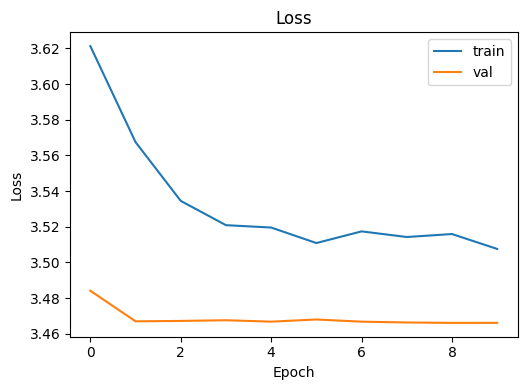

In [20]:
model_clip = create_clip_model()
trained_model = train_clip_model(model_clip, ds_train, ds_test, ds_val, model_save_path=saved_models_path, epochs=10)

Model: "Clip"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (32, 224, 224, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (32, 32)          │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_6        │ (32, 128)         │     51,360 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_7        │ (32, 128)         │  1,978,368 │ text_input[0][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l2_normalize_80     │ (32, 128)         │          0 │ functional_6[1][… │
│ (L2Normalize)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l2_normalize_81     │ (32, 128)         │          0 │ functional_7[1][… │
│ (L2Normalize)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clip_loss_layer_38  │ [(32, 128), (32,  │          0 │ l2_normalize_80[… │
│ (ClipLossLayer)     │ 128)]             │            │ l2_normalize_81[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,029,728 (7.74 MB)

 Trainable params: 2,029,472 (7.74 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - clip_loss: 3.4122 - loss: 3.4122
Epoch 1: val_clip_loss improved from inf to 3.42676, saving model to ./models_forclip/best_clip.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - clip_loss: 3.4098 - loss: 3.4098 - val_clip_loss: 3.4268 - val_loss: 3.4268
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - clip_loss: 3.2764 - loss: 3.2764
Epoch 2: val_clip_loss did not improve from 3.42676
12/12 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - clip_loss: 3.2741 - loss: 3.2741 - val_clip_loss: 3.5030 - val_loss: 3.5030
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - clip_loss: 3.1721 - loss: 3.1721
Epoch 3: val_clip_loss did not improve from 3.42676
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - clip_loss: 3.1712 - loss: 3.1712 - val_clip_loss: 3.6932 - val_loss: 3.6932
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - clip_loss: 3.1181 - loss: 3.1181
Epoch 4: val_clip_loss did not improve from 3.42676
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - clip_loss: 3.1

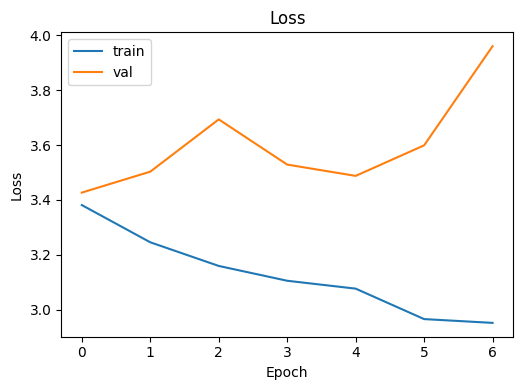

In [137]:
model_clip = create_clip_model()
trained_model = train_clip_model(model_clip, ds_train, ds_test, ds_val, model_save_path=saved_models_path, epochs=15)

Avec une patience de 6 et 15 epochs, on remarque qu'il n'y a pas de palier d'amélioration à dépasser.

## Creation Embeddings

In [21]:
def load_img_224(p):
  x = tf.io.read_file(p)
  x = tf.image.decode_jpeg(x, channels=3)
  x = tf.image.convert_image_dtype(x, tf.float32)  # [0,1]
  x = tf.image.resize(x,[224, 224])
  return x

In [22]:
model_name="best_clip.keras"
clip = tf.keras.models.load_model(os.path.join(saved_models_path, model_name))

In [81]:
input = Input(shape=(224, 224, 3), batch_size=None, name="image_input")
image_emb = clip.get_layer("model_image")(input)
normalized_img_emb = L2Normalize()(image_emb)
make_emb_img = Model(inputs=input, outputs=normalized_img_emb)
make_emb_img.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ model_image (Functional)        │ (None, 128)            │        51,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize_12 (L2Normalize)   │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,360 (200.62 KB)

 Trainable params: 51,360 (200.62 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
gallery_paths = []
for p in df["image_path"].values.tolist():
  if Path(p).rglob("*.jpg"):
    gallery_paths.append(dataset_dir+"/"+str(p))

ds_gallery = tf.data.Dataset.from_tensor_slices(gallery_paths)
ds_gallery = (ds_gallery.map(load_img_224, num_parallel_calls=AUTOTUNE)
              .batch(32,drop_remainder=False).prefetch(AUTOTUNE))
gallery_embeds = make_emb_img.predict(ds_gallery)

19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 792ms/step


In [83]:
# Vérification de la normalisation
norms = tf.norm(gallery_embeds, axis=-1)
print(norms.numpy()[:10])

[0.99999994 1.         1.         0.99999994 0.99999994 0.99999994
 1.         0.99999994 1.         1.        ]


In [85]:
input = Input(shape=(32,), batch_size=None, name="image_input")
text_emb = clip.get_layer("model_text")(input)
normalized_txt_emb = L2Normalize()(text_emb)
make_emb_txt = Model(inputs=input, outputs=normalized_txt_emb)

make_emb_txt.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ model_text (Functional)         │ (None, 128)            │     1,978,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize_14 (L2Normalize)   │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,978,368 (7.55 MB)

 Trainable params: 1,978,112 (7.55 MB)

 Non-trainable params: 256 (1.00 KB)

In [86]:
captions = []
for c in df["caption"].values.tolist():
  captions.append(str(c))

ds_captions = (tf.data.Dataset.from_tensor_slices(captions).map(vectorize_layer, num_parallel_calls=AUTOTUNE).batch(32,drop_remainder=False).prefetch(AUTOTUNE))
captions_embeds = make_emb_txt.predict(ds_captions)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'mean_no_pad' (of type MaskedMean) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step


In [129]:
# Vérification de la normalisation
norms = tf.norm(captions_embeds, axis=-1)
print(norms.numpy()[:10])

[1.        1.        0.9999999 1.        0.9999998 0.9999999 1.
 1.        1.        1.       ]


## Sauvegarde Embeddings

In [87]:
index_path = os.path.join(saved_models_path, "image_index.npz")
np.savez_compressed(
    index_path,
    embeds=gallery_embeds.astype("float32"),
    paths=np.array(gallery_paths, dtype=np.str_)
)
print("Index enregistré à :", index_path,
      "- shape des embeddings :", gallery_embeds.shape)

Index enregistré à : ./models_forclip/image_index.npz - shape des embeddings : (600, 128)


In [88]:
# Sauvegarde compressée de l'index texte
text_index_path = os.path.join(saved_models_path, "text_index.npz")
np.savez_compressed(
    text_index_path,
    embeds=captions_embeds.astype("float32"),
    captions=np.array(captions, dtype=np.str_),
    image_paths=df["image_path"].astype(str).to_numpy(dtype=np.str_)
)
print("Index texte sauvegardé:",
      text_index_path, " - shape :", captions_embeds.shape)

Index texte sauvegardé: ./models_forclip/text_index.npz  - shape : (600, 128)


## Prédiction

In [89]:
data_img  = np.load(os.path.join(saved_models_path, "image_index.npz"))
embeds_img = data_img["embeds"]         # Le format doit être (N, D)
paths  = data_img["paths"].astype(str) # Le format doit (N,)
print(embeds_img.shape, len(paths))

data_txt  = np.load(os.path.join(saved_models_path, "text_index.npz"))
embeds_txt = data_txt["embeds"]         # Le format doit être (N, D)
captions  = data_txt["captions"].astype(str) # Le format doit (N,)
image_paths = data_txt["image_paths"]
print(embeds_txt.shape, len(captions))

(600, 128) 600
(600, 128) 600


In [90]:
def show_image(img, title=None, cmap=None):
  img = Image.open(img)
  img = np.array(img)
  plt.imshow(img)
  plt.title(title)

  plt.axis('off')
  plt.show()

In [133]:
def get_img_from_sentence(sentence):
  vectorized_sentence = vectorize_layer(sentence)
  vectorized_sentence = tf.reshape(vectorized_sentence, [1, 32])
  q = make_emb_txt.predict(vectorized_sentence)

  scores = (q  @ embeds_img.T)[0]
  k = 5
  idx = np.argpartition(scores,-k)[-k:]
  top_scores = scores[idx]
  sorted_k_idx = idx[np.argsort(top_scores)[::-1]]

  for i in sorted_k_idx:
    show_image(dataset_dir + "/" + image_paths[i], scores[i])

In [130]:
def get_sentence_from_img(path):
  show_image(path)

  img = load_img_224(path)
  img = tf.reshape(img, [1, 224, 224, 3])

  q = make_emb_img.predict(img)

  scores = (q  @ embeds_txt.T)[0]
  k = 5
  idx = np.argpartition(scores,-k)[-k:]
  top_scores = scores[idx]
  sorted_k_idx = idx[np.argsort(top_scores)[::-1]]

  for i in sorted_k_idx:
    print(f"Sentence : {captions[i]}\nScore : {scores[i]}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


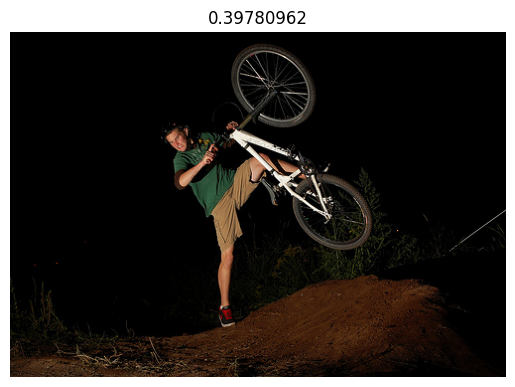

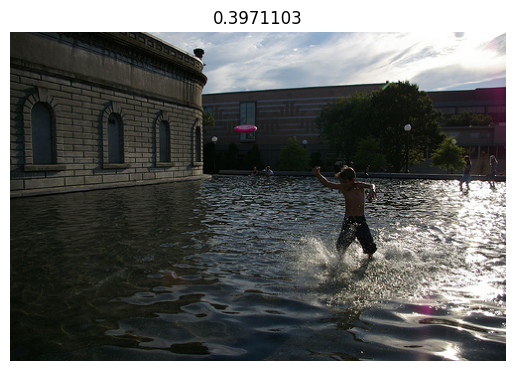

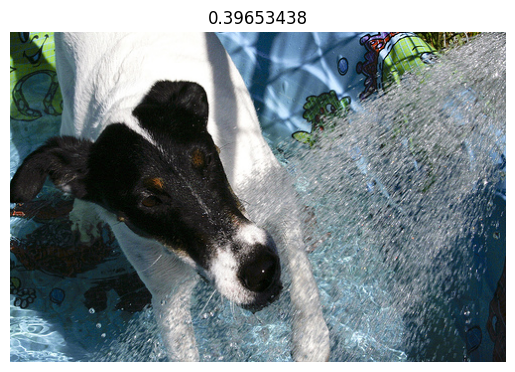

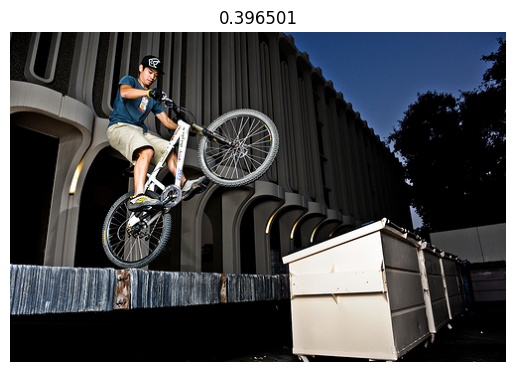

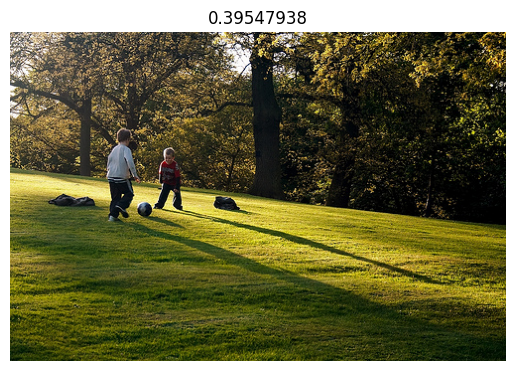

In [134]:
get_img_from_sentence("A bike")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


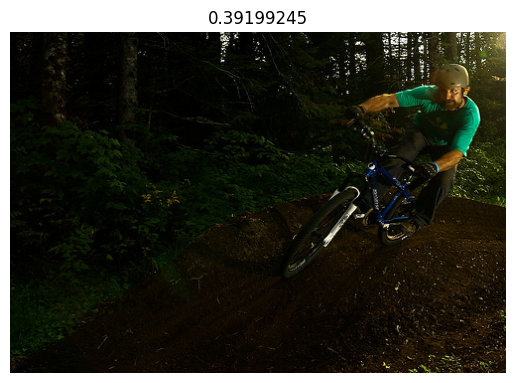

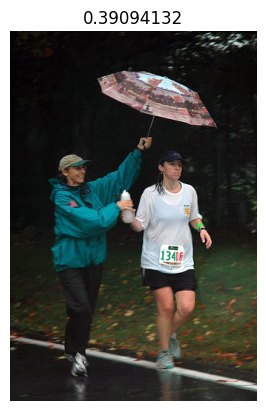

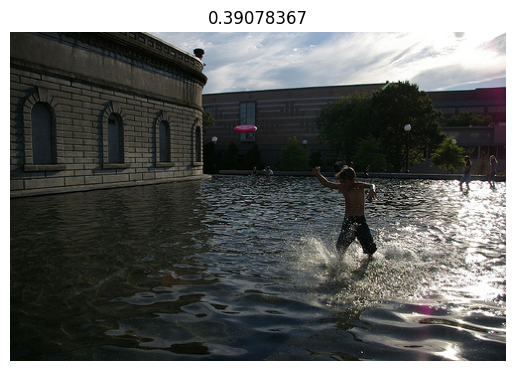

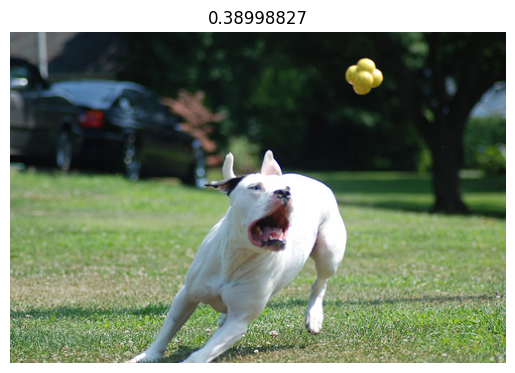

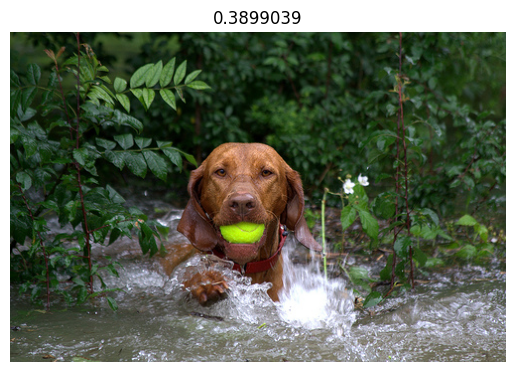

In [135]:
get_img_from_sentence("Two balls")

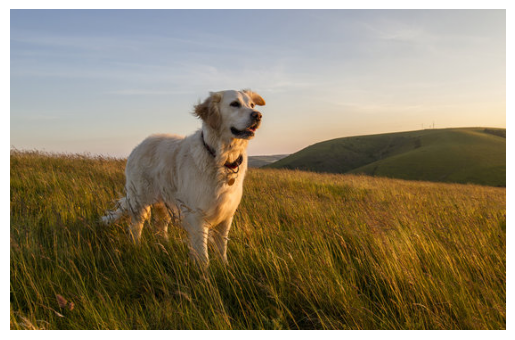

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Sentence : A child plays T-ball .
Score : 0.4062333106994629

Sentence : a crowd wearing red , cheers on the red football team .
Score : 0.40129268169403076

Sentence : a football player in a red jersey getting his knee looked at by another man
Score : 0.4001426696777344

Sentence : A boy plays basketball .
Score : 0.39954379200935364

Sentence : A group of football players are playing football .
Score : 0.39883413910865784



In [131]:
path = dataset_dir + "/images/chien_test_clip.jpg"
get_sentence_from_img(path)

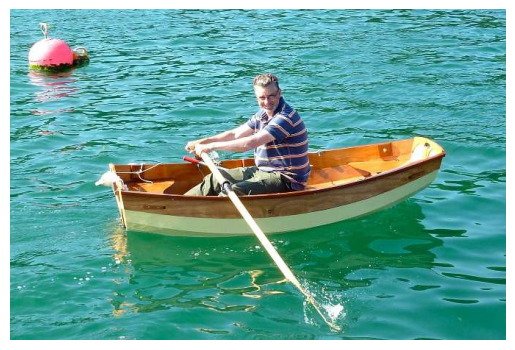

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
Sentence : A child plays T-ball .
Score : 0.40617039799690247

Sentence : a crowd wearing red , cheers on the red football team .
Score : 0.4011397361755371

Sentence : a football player in a red jersey getting his knee looked at by another man
Score : 0.39999520778656006

Sentence : A boy plays basketball .
Score : 0.3994595408439636

Sentence : A group of football players are playing football .
Score : 0.39875328540802



In [132]:
path = dataset_dir + "/images/water_test_clip.jpg"
get_sentence_from_img(path)